# Softmax 回归
在上一节线性回归的基础上，变成多输出，加个 softmax 层

## 1 类别编码
- 1-hot 编码
$$y = [y_1, y_2, ..., y_n]^T$$
$$y_i = \begin{cases} 1, & \text{if i = y} \\ 0, & \text{otherwise} \end{cases}$$

- 最大值为预测类别
$$\hat{y} = \arg\max_i o_i$$

## 2 交叉熵损失
- 交叉熵 $$H(p, q) = -\sum_x p(x) \log q(x)$$

- 交叉熵损失函数（$y_y=1$，其他为 $0$） $$l = -\sum_i y_i \log \hat{y}_i = -\log \hat{y}_y$$




# 图像分类数据集

Fashion-MNIST 数据集


In [3]:
%matplotlib inline
import torch
import torchvision
from torchvision import transforms
from torch.utils import data
from matplotlib import pyplot as plt
import util

下载 Fashion-MNIST 数据集，并读入内存

In [4]:
# 将图像数据从 PIL 类型转换为 tensor 类型，并将像素值归一化到 [0, 1] 区间
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=trans, download=True)
len(mnist_train), len(mnist_test), mnist_train[0][0].shape # 第二维 [0] 是图像，[1] 是标签

(60000, 10000, torch.Size([1, 28, 28]))

两个可视化数据集的函数

array([<Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'dress'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'trouser'}>,
       <Axes: title={'center': 't-shirt'}>], dtype=object)

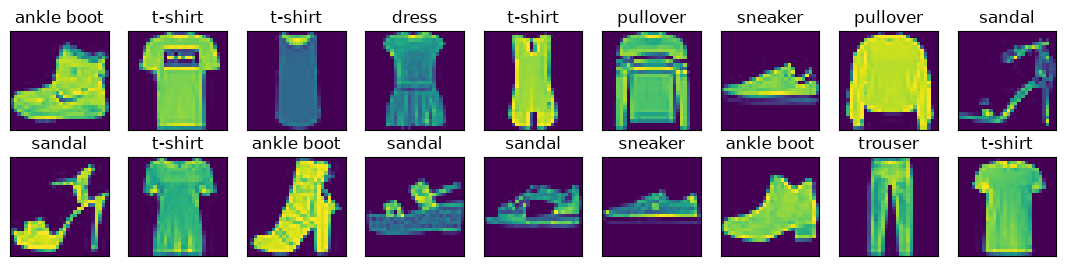

In [5]:
def get_fashion_mnist_labels(labels):
    """返回 Fashion-MNIST 数据集的文本标签"""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """绘制图像列表"""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten() # 将二维数组展平为一维数组
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img): # 图片张量
            ax.imshow(img.numpy())
        else: # PIL 图片
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

# 取 18 个样例展示
X, y = next(iter(data.DataLoader(mnist_train, batch_size=18)))
show_images(X.reshape(18, 28, 28), 2, 9, titles=get_fashion_mnist_labels(y))

读取小批量数据，使用多进程加速

In [6]:
batch_size = 256
def get_dataloader_workers():
    """使用多进程读取数据"""
    return 4
train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=get_dataloader_workers())

定义 load_data_fashion_mnist 函数

In [7]:
def load_data_fashion_mnist(batch_size, resize=None):
    """下载 Fashion-MNIST 数据集，然后将其加载到内存中
    :param batch_size: 批量大小
    :param resize: 图像大小
    :return: (训练集, 测试集) 的迭代器
    """
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=trans, download=True)
    return (data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_test, batch_size, shuffle=False, num_workers=get_dataloader_workers()))

# Softmax 回归的从零开始实现


In [12]:
from util import Animator, Accumulator

batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size)


展平图像，将 28x28 的图像变成长度为 784 的向量，输出 10 类。


In [13]:
num_inputs = 784
num_outputs = 10

class SoftmaxRegression():
    """Softmax 回归模型"""
    def __init__(self, num_inputs, num_outputs):
        self.num_inputs = num_inputs
        self.num_outputs = num_outputs
        self.w = torch.normal(0, 0.01, size=(self.num_inputs, self.num_outputs), requires_grad=True)
        self.b = torch.zeros(self.num_outputs, requires_grad=True)
    @staticmethod
    def softmax(x):
        """Softmax 函数"""
        x_exp = torch.exp(x)
        partition = x_exp.sum(1, keepdim=True) # 按行求和
        return x_exp / partition  # 广播机制
    @staticmethod
    def cross_entropy(y_hat, y):
        """交叉熵损失函数"""
        # 每列索引是 y 中的一个元素（y = [batch], y_hat = [batch, num_classes]）
        return -torch.log(y_hat[range(len(y_hat)), y])
    @staticmethod
    def accuracy(y_hat, y):
        """计算预测正确的数量"""
        if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
            y_hat = y_hat.argmax(axis=1) # 取最大值的索引
        cmp = y_hat.type(y.dtype) == y
        return float(cmp.type(y.dtype).sum())

    def forward(self, x):
        # 变形为 [batch x features]
        return self.softmax(torch.matmul(x.reshape((-1, self.w.shape[0])), self.w) + self.b)

    def evaluate_accuracy(self, data_iter):
        """计算在指定数据集上模型的精度"""
        metric = Accumulator(2)  # 正确预测数、预测总数
        for X, y in data_iter:
            metric.add(self.accuracy(self.forward(X), y), y.numel())
        return metric[0] / metric[1]

    def train_epoch(self, train_iter, updater):
        """训练模型一个迭代周期"""
        metric = Accumulator(3)
        for X, y in train_iter:
            y_hat = self.forward(X)
            l = self.cross_entropy(y_hat, y)
            l.sum().backward() # 反向传播计算梯度
            updater(X.shape[0])
            metric.add(float(l.sum()), self.accuracy(y_hat, y), y.numel())
        # 返回训练损失、正确率
        return metric[0] / metric[2], metric[1] / metric[2]

    def train(self, train_iter, test_iter, num_epochs, updater):
        """训练模型"""
        animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                            legend=['train loss', 'train acc', 'test acc'])
        for epoch in range(num_epochs):
            train_metrics = self.train_epoch(train_iter, updater)
            test_acc = self.evaluate_accuracy(test_iter)
            animator.add(epoch + 1, train_metrics + (test_acc,))
        train_loss, train_acc = train_metrics
    def updater(self, batch_size):
        util.sgd([self.w, self.b], lr=0.1, batch_size=batch_size)



正式训练，迭代 10 个周期


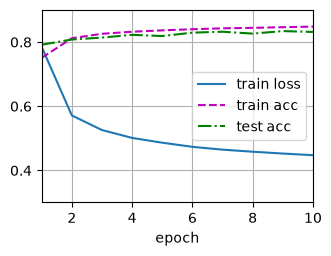

In [14]:
num_epochs = 10
model = SoftmaxRegression(num_inputs, num_outputs)
updater = model.updater
model.train(train_iter, test_iter, num_epochs, updater)

检查训练效果


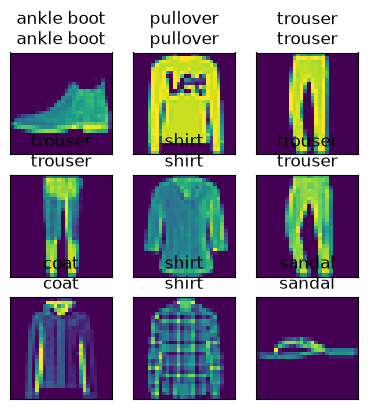

In [15]:
def predict(model, test_iter):
    """预测模型在测试集上的结果"""
    for X, y in test_iter:
        break
    trues = get_fashion_mnist_labels(y)
    preds = get_fashion_mnist_labels(model.forward(X).argmax(dim=1))
    titles = [true + '\n' + pred for true, pred in zip(trues, preds)]
    show_images(X[0:9].reshape(9, 28, 28), 3, 3, titles=titles[0:9])

predict(model, test_iter)

# Softmax 回归的简洁实现


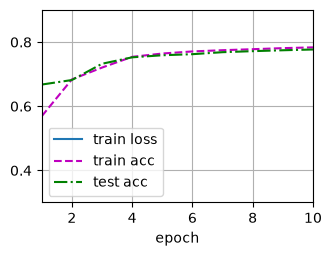

In [17]:
from torch import nn
import util

class SoftmaxRegressionSimple(nn.Module):
    """Softmax 回归模型"""
    def __init__(self, num_inputs, num_outputs):
        super().__init__()
        self.flatten = nn.Flatten() # 展平层
        self.linear = nn.Linear(num_inputs, num_outputs)
        self.softmax = nn.Softmax(dim=1)
        self.loss = nn.CrossEntropyLoss()
        self.trainer = torch.optim.SGD(self.parameters(), lr=0.1)
        self.init_weights()

    def init_weights(self):
        """初始化权重"""
        nn.init.normal_(self.linear.weight, mean=0, std=0.01)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x):
        return self.softmax(self.linear(self.flatten(x)))

    def train_ch3(self, train_iter, test_iter, num_epochs):
        util.train_ch3(self, train_iter, test_iter, self.loss, num_epochs, self.trainer)

model = SoftmaxRegressionSimple(num_inputs, num_outputs)
model.train_ch3(train_iter, test_iter, num_epochs)